In [29]:
# ----------- Load Required Libraries -----------
library(phyloseq)
library(ANCOMBC)
library(ggplot2)
library(ggrepel)
library(dplyr)
library(tibble)
library(forcats)

In [18]:
# ----------- Load Phyloseq Object -----------
ps <- readRDS("/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_inputs/GP_ps.st.decontam.rds")
# Define Figure path
path.figures <- "/scratch/negishi/ldas/COW_INFLAMMATION/Figures"

In [55]:
## ANCOMBC ##
# ----------- Define Universal ANCOM-BC2 and Plot Function -----------
run_ancombc2_plot <- function(ps, variable, label) {
  
  # Subset samples where the metadata variable is not NA
  keep_samples <- !is.na(sample_data(ps)[[variable]])
ps_sub <- prune_samples(keep_samples, ps)


  # Collapse the phyloseq object to Genus level
  ps_genus <- tax_glom(ps_sub, taxrank = "Genus")

  # Filter taxa: keep only those with count >1 in at least one sample
  ps_genus_filtered <- filter_taxa(ps_genus, function(x) any(x > 1), prune = TRUE)


  # ----------- Run ANCOM-BC2 to test differential abundance by the specified variable -----------
  ancom_out <- ancombc2(
    data = ps_genus_filtered,
    assay_name = "counts",
    tax_level = "Genus",
    fix_formula = variable,           # Model formula using the selected variable (e.g., Fibrinogen_InflamStat)
    rand_formula = NULL,              # No random effects; assumes independent samples
    p_adj_method = "fdr",             # Benjamini-Hochberg correction
    group = variable,                 # Group used to compute fold changes
    struc_zero = TRUE,                # Apply structural zero filtering
    neg_lb = FALSE,                   # Exclude taxa with negative lower CI bound (more conservative)
    alpha = 0.05,                     # Significance cutoff for adjusted p-values
    global = FALSE                    # Skip global test; only run pairwise comparison
  )

  # ----------- Extract relevant statistics (log fold change, SE, p-value, q-value) -----------
  res_df <- data.frame(
    Taxon = ancom_out$res$taxon,
    lfc   = ancom_out$res[[paste0("lfc_", variable, "Normal")]],
    se    = ancom_out$res[[paste0("se_", variable, "Normal")]],
    pval  = ancom_out$res[[paste0("p_", variable, "Normal")]],
    padj  = ancom_out$res[[paste0("q_", variable, "Normal")]],
    stringsAsFactors = FALSE
  )

  # ----------- Merge ANCOM-BC2 results with taxonomy table -----------
  tax_tab <- tax_table(ps_genus_filtered) %>%
    as.data.frame() %>%
    rownames_to_column("Taxon")

  res_annotated <- left_join(res_df, tax_tab, by = "Taxon")

  # ----------- Assign Genus name directly from the Taxon label (already at Genus level) -----------
  res_annotated$Genus <- res_annotated$Taxon

  # ----------- Define significance based on p-value threshold -----------
  log2FC_threshold <- 1        # Fold change threshold (for visual reference, not filtering here)
  pval_threshold <- 0.05       # p-value cutoff for significance
  res_annotated$Significance <- ifelse(res_annotated$pval < pval_threshold,
                                       "Differentially Abundant", "Not Significant")

  # ----------- Select top 25 most significant genera for labeling in the volcano plot -----------
  top_to_label <- res_annotated %>%
    filter(Significance != "Not Significant") %>%
    arrange(pval) %>%
    slice_head(n = 25)

  # ----------- Create volcano plot -----------
  p_volcano <- ggplot(res_annotated, aes(x = lfc, y = -log10(pval), color = Significance)) +
    geom_point(alpha = 0.8, size = 1.5) +                             # Scatter plot of all taxa
    geom_text_repel(data = top_to_label,                             # Label top 25 significant genera
                    aes(label = Genus),
                    size = 3.5,
                    max.overlaps = Inf,
                    box.padding = 0.4,
                    point.padding = 0.3,
                    segment.color = "grey50") +
    scale_color_manual(values = c(
      "Differentially Abundant" = "forestgreen",
      "Not Significant" = "gray"
    )) +
    geom_vline(xintercept = c(-log2FC_threshold, log2FC_threshold),  # Vertical lines for fold change threshold
               linetype = "dashed", color = "black") +
    geom_hline(yintercept = -log10(pval_threshold),                  # Horizontal line for p-value cutoff
               linetype = "dashed", color = "black") +
    theme_minimal(base_size = 14) +
    labs(
      title = paste("Significantly Altered Genera —", label),        # Plot title
      x = expression(Log[2]~FoldChange),
      y = expression(-Log[10]~p~value),
      color = NULL
    ) +
    theme(legend.position = "top")

  # ----------- Save results and volcano plot to output directory -----------
  write.csv(res_annotated,
            file.path(path.figures, paste0("ancombc2_genus_", tolower(variable), "_results.csv")),
            row.names = FALSE)

  ggsave(
    filename = file.path(path.figures, paste0("volcano_ancombc2_genus_", tolower(variable), ".png")),
    plot = p_volcano,
    width = 9, height = 6, dpi = 300
  )

  ggsave(
    filename = file.path(path.figures, paste0("volcano_ancombc2_genus_", tolower(variable), ".tiff")),
    plot = p_volcano,
    width = 9, height = 6, dpi = 300,
    device = "tiff"
  )

  # ----------- Return results and plot  -----------

  print(p_volcano)

  # ----------- Return results for downstream use -----------
  return(res_annotated)
} 


Checking the input data type ...

The input data is of type: phyloseq

PASS

Checking the sample metadata ...

The specified variables in the formula: Fibrinogen_InflamStat

The available variables in the sample metadata: X, Sample_ID, Corrected_Sample_ID, Cow_ID, DIM_Collected, Date_Collected, Date_Recieved, Farm, Sample_Type, Sex, BCS, Parity, Housing_type, Fibrinogen_1DIM, Fibrinogen_3DIM, Fibrinogen_7DIM, Fibrinogen_InflamStat, FIBRINOGEN_MEAN, MeanFibrinogen_InflamStat, Haptoglobin_1DIM, Haptoglobin_3DIM, Haptoglobin_InflamStat, ExtractionDate, ExtractionKit, DNAElutionVolume, DNAYield_ng, qpcr_16s_copies_ul, BarcodeSequence, LinkerPrimerSequence, ReverseSequence, general.rawsamplename, general.readlength, general.readlengthr2, general.runname, general.samplename, subsample.rawreads, subsample.subsampledreads, fastqc.meanreadqualityR1, fastqc.meanreadqualityR2, fastqc.meanreadqualityR2.1, fastqc.pct.deduplicated, fastqc.pct.dimer, fastqc.pct.gc, fastqc.sequencelength, fastqc.total

Taxon,lfc,se,pval,padj,Kingdom,Phylum,Class,Order,Family,Genus,Species,Significance
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Methanobrevibacter,0.12917222,0.1189573,0.28068002,0.5543430,NA,NA,NA,NA,NA,Methanobrevibacter,NA,Not Significant
Bifidobacterium,0.30115558,0.1872899,0.11193576,0.3964041,NA,NA,NA,NA,NA,Bifidobacterium,NA,Not Significant
Atopobium,-0.15034813,0.1075683,0.17075747,0.4695982,NA,NA,NA,NA,NA,Atopobium,NA,Not Significant
Olsenella,0.01315777,0.1092718,0.90461992,0.9403286,NA,NA,NA,NA,NA,Olsenella,NA,Not Significant
Adlercreutzia,0.10768080,0.1086580,0.33740036,0.6198751,NA,NA,NA,NA,NA,Adlercreutzia,NA,Not Significant
Berryella,-0.04593140,0.1100766,0.67883071,0.9034674,NA,NA,NA,NA,NA,Berryella,NA,Not Significant
Anaeroplasma,0.27487005,0.1093978,0.02596552,0.2828924,NA,NA,NA,NA,NA,Anaeroplasma,NA,Differentially Abundant
UCG-004,0.10252881,0.1071563,0.34561789,0.6205412,NA,NA,NA,NA,NA,UCG-004,NA,Not Significant
Anaerorhabdus,0.06150643,0.1063353,0.56860218,0.8660783,NA,NA,NA,NA,NA,Anaerorhabdus,NA,Not Significant


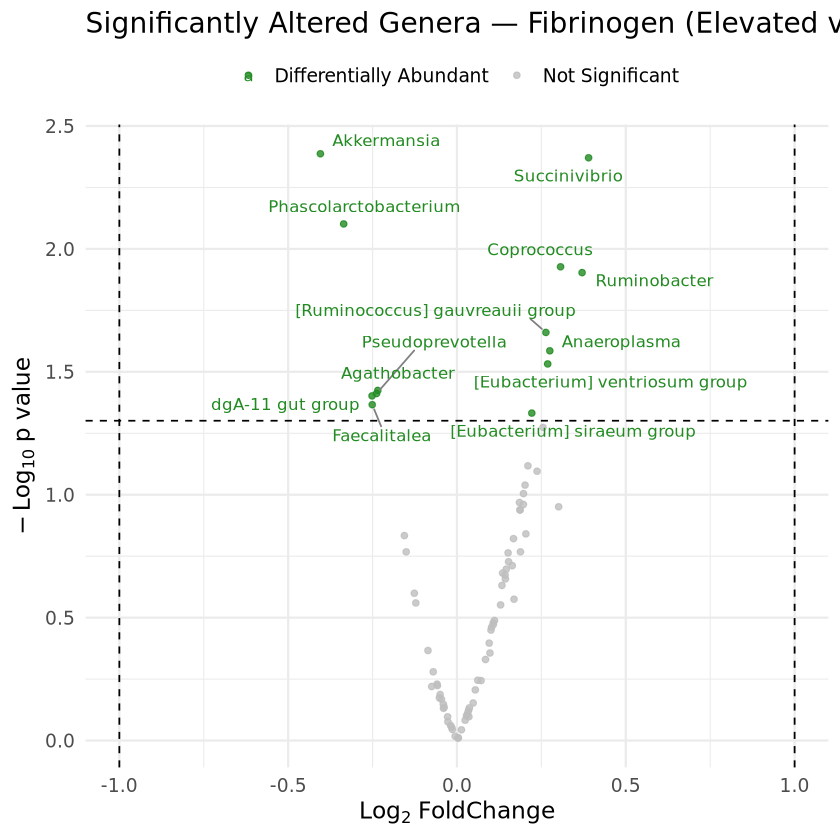

In [56]:
# Run for Fibrinogen
run_ancombc2_plot(ps, variable = "Fibrinogen_InflamStat", label = "Fibrinogen (Elevated vs Normal)")


In [57]:
class(res_fibrinogen)
# [1] "list"


[1] "gg"     "ggplot"

In [53]:
library(ggplot2)
library(dplyr)
library(forcats)

# ----------- Extract Top 30 Differential Genera from Result Table -----------
sig_genera <- res_fibrinogen %>%
  filter(Significance == "Differentially Abundant") %>%
  arrange(desc(abs(lfc))) %>%
  slice_head(n = 30) %>%
  mutate(Genus = fct_reorder(Genus, lfc))  # for ordered y-axis

# ----------- Build Lollipop Plot -----------
p_lollipop_fibrinogen <- ggplot(sig_genera, aes(x = lfc, y = Genus)) +
  geom_segment(aes(x = 0, xend = lfc, y = Genus, yend = Genus),
               color = "grey60", size = 0.6) +
  geom_point(aes(color = lfc > 0), size = 3) +
  scale_color_manual(values = c("TRUE" = "forestgreen", "FALSE" = "red"),
                     labels = c("More in Normal", "More in Elevated"),
                     name = NULL) +
  labs(
    title = "Top 30 Differentially Abundant Genera — Fibrinogen",
    x = expression(Log[2]~FoldChange~(Normal/Elevated)),
    y = NULL
  ) +
  theme_minimal(base_size = 14) +
  theme(
    legend.position = "top",
    panel.grid.major.y = element_blank()
  )

# ----------- Save Plot -----------
ggsave(file.path(path.figures, "lollipop_fibrinogen.png"),
       p_lollipop_fibrinogen, width = 8, height = 6, dpi = 300)

ggsave(file.path(path.figures, "lollipop_fibrinogen.tiff"),
       p_lollipop_fibrinogen, width = 8, height = 6, dpi = 300, device = "tiff")

# ----------- Display Plot -----------
print(p_lollipop_fibrinogen)


ERROR: Error in UseMethod("filter"): no applicable method for 'filter' applied to an object of class "c('gg', 'ggplot')"


Checking the input data type ...

The input data is of type: phyloseq

PASS

Checking the sample metadata ...

The specified variables in the formula: Haptoglobin_InflamStat

The available variables in the sample metadata: X, Sample_ID, Corrected_Sample_ID, Cow_ID, DIM_Collected, Date_Collected, Date_Recieved, Farm, Sample_Type, Sex, BCS, Parity, Housing_type, Fibrinogen_1DIM, Fibrinogen_3DIM, Fibrinogen_7DIM, Fibrinogen_InflamStat, FIBRINOGEN_MEAN, MeanFibrinogen_InflamStat, Haptoglobin_1DIM, Haptoglobin_3DIM, Haptoglobin_InflamStat, ExtractionDate, ExtractionKit, DNAElutionVolume, DNAYield_ng, qpcr_16s_copies_ul, BarcodeSequence, LinkerPrimerSequence, ReverseSequence, general.rawsamplename, general.readlength, general.readlengthr2, general.runname, general.samplename, subsample.rawreads, subsample.subsampledreads, fastqc.meanreadqualityR1, fastqc.meanreadqualityR2, fastqc.meanreadqualityR2.1, fastqc.pct.deduplicated, fastqc.pct.dimer, fastqc.pct.gc, fastqc.sequencelength, fastqc.tota

Taxon,lfc,se,pval,padj,Kingdom,Phylum,Class,Order,Family,Genus,Species,Significance
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Methanobrevibacter,0.0449523426,0.09471915,6.363287e-01,0.797935984,NA,NA,NA,NA,NA,Methanobrevibacter,NA,Not Significant
Bifidobacterium,0.4429758978,0.21811796,4.571700e-02,0.164165591,NA,NA,NA,NA,NA,Bifidobacterium,NA,Differentially Abundant
Atopobium,-0.0163391129,0.06227256,7.945237e-01,0.863263177,NA,NA,NA,NA,NA,Atopobium,NA,Not Significant
Olsenella,-0.3345397125,0.07806729,7.909569e-05,0.001562140,NA,NA,NA,NA,NA,Olsenella,NA,Differentially Abundant
Adlercreutzia,-0.0006750484,0.05615053,9.905664e-01,0.990566409,NA,NA,NA,NA,NA,Adlercreutzia,NA,Not Significant
Berryella,-0.2180271951,0.06858294,2.936421e-03,0.028363540,NA,NA,NA,NA,NA,Berryella,NA,Differentially Abundant
Anaeroplasma,0.1543823268,0.05664518,1.733243e-02,0.076070116,NA,NA,NA,NA,NA,Anaeroplasma,NA,Differentially Abundant
UCG-004,0.0837474278,0.05682489,1.500167e-01,0.338691757,NA,NA,NA,NA,NA,UCG-004,NA,Not Significant
Anaerorhabdus,-0.0106959942,0.05575528,8.495525e-01,0.889184302,NA,NA,NA,NA,NA,Anaerorhabdus,NA,Not Significant


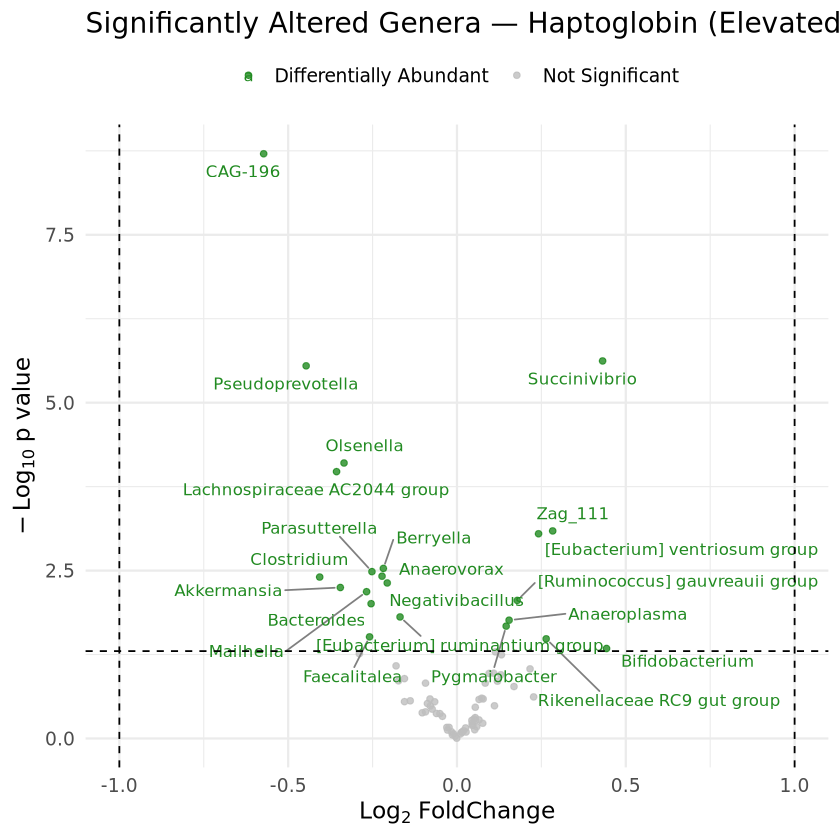

In [47]:
# Run for Haptoglobin
run_ancombc2_plot(ps, variable = "Haptoglobin_InflamStat", label = "Haptoglobin (Elevated vs Normal)")


In [62]:
# ----------- Filter for Significant Genera Only -----------
sig_genera <- res_annotated %>%
  filter(Significance == "Differentially Abundant") %>%
  arrange(desc(abs(lfc))) %>%
  slice_head(n = 30) %>%   # top 30 genera
  mutate(Genus = fct_reorder(Genus, lfc))  # reorder for plotting

# ----------- Create Lollipop Plot -----------
p_lollipop <- ggplot(sig_genera, aes(x = lfc, y = Genus)) +
  geom_segment(aes(x = 0, xend = lfc, y = Genus, yend = Genus),
               color = "grey60", size = 0.6) +
  geom_point(aes(color = lfc > 0), size = 3) +
  scale_color_manual(values = c("TRUE" = "forestgreen", "FALSE" = "red"),
                     labels = c("More in Normal", "More in Elevated"),
                     name = NULL) +
  labs(
    title = "Top 30 Differentially Abundant Genera",
    x = expression(Log[2]~FoldChange~(Normal/Elevated)),
    y = NULL
  ) +
  theme_minimal(base_size = 14) +
  theme(
    legend.position = "top",
    panel.grid.major.y = element_blank()
  )

# ----------- Save Plot -----------
ggsave(
  filename = file.path(path.figures, "lollipop_ancombc2_genus.png"),
  plot = p_lollipop,
  width = 8, height = 6, dpi = 300
)

ggsave(
  filename = file.path(path.figures, "lollipop_ancombc2_genus.tiff"),
  plot = p_lollipop,
  width = 8, height = 6, dpi = 300,
  device = "tiff"
)

# ----------- Display -----------
print(p_lollipop)


ERROR: Error in UseMethod("filter"): no applicable method for 'filter' applied to an object of class "NULL"
